# Anillos y rectángulos con contornos

Este notebook genera un dataset 2D binario inspirado en el esquema de anillos arriba y rectángulos abajo, y luego muestra cómo clasifican varios modelos de `scikit-learn`.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [26]:
rng = np.random.default_rng(7)

def sample_ring(center, n=220, radius=1.25, noise=0.05):
    theta = rng.uniform(0, 2 * np.pi, n)
    r = radius + rng.normal(0, noise, n)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    return np.column_stack([x, y])

def sample_multi_ring(center, radii, points_per_ring=180, noise=0.05):
    return np.vstack([
        sample_ring(center, n=points_per_ring, radius=radius, noise=noise)
        for radius in radii
    ])

def sample_rectangle_ring(center, width=1.8, height=1.3, n=260, noise=0.04):
    pts = []
    for _ in range(n):
        side = rng.integers(0, 4)
        t = rng.uniform(-0.5, 0.5)
        if side == 0:
            x, y = width * t, height / 2
        elif side == 1:
            x, y = width * t, -height / 2
        elif side == 2:
            x, y = width / 2, height * t
        else:
            x, y = -width / 2, height * t
        pts.append([center[0] + x + rng.normal(0, noise), center[1] + y + rng.normal(0, noise)])
    return np.array(pts)

def sample_multi_rectangle_ring(center, width, height, scales, points_per_ring=220, noise=0.04):
    return np.vstack([
        sample_rectangle_ring(center, width=width * scale, height=height * scale, n=points_per_ring, noise=noise)
        for scale in scales
    ])

In [27]:
red_centers = [(3.0, 8.5), (7.5, 7.2), (12.0, 8.6)]
red_radii = [0.45, 0.85, 1.25]
blue_specs = [
    ((3.0, 2.1), 1.6, 1.9, [0.45, 0.75, 1.0]),
    ((7.5, 4.2), 5.2, 1.4, [0.45, 0.75, 1.0]),
    ((12.0, 2.1), 1.6, 1.9, [0.45, 0.75, 1.0]),
]

red_points = np.vstack([
    sample_multi_ring(center, radii=red_radii, points_per_ring=170, noise=0.05)
    for center in red_centers
])
blue_points = np.vstack([
    sample_multi_rectangle_ring(center, width=width, height=height, scales=scales, points_per_ring=180, noise=0.04)
    for center, width, height, scales in blue_specs
])

df_red = pd.DataFrame(red_points, columns=["x1", "x2"])
df_red["label"] = 1
df_blue = pd.DataFrame(blue_points, columns=["x1", "x2"])
df_blue["label"] = 0
df = pd.concat([df_blue, df_red], ignore_index=True)

X = df[["x1", "x2"]].to_numpy()
y = df["label"].to_numpy()
palette = {0: "#2b78c5", 1: "#e53935"}
df.head()

,x1,x2,label
0,2.929187,2.619307,0
1,2.639241,2.348977,0
2,2.643508,1.854993,0
3,2.869438,1.698886,0
4,2.613186,1.651107,0


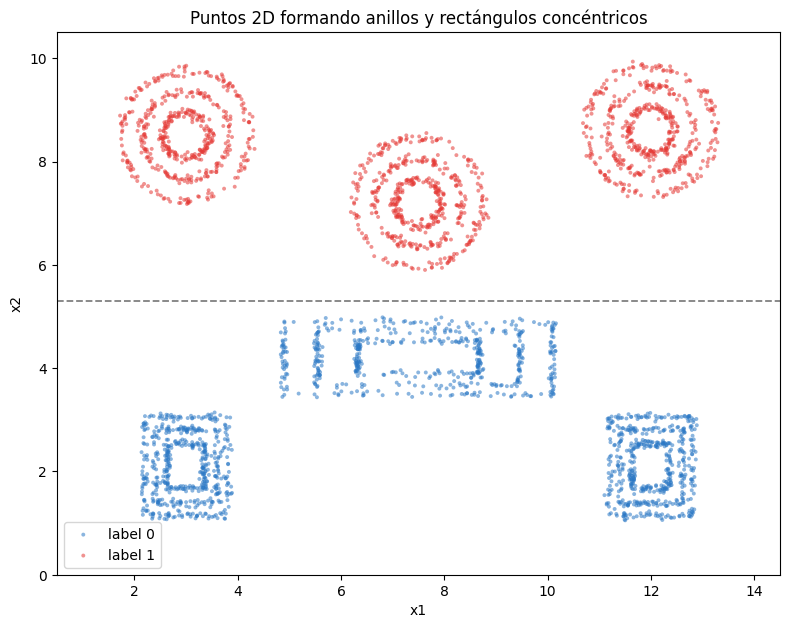

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))
for label, color in palette.items():
    subset = df[df["label"] == label]
    ax.scatter(subset["x1"], subset["x2"], s=8, c=color, alpha=0.55, edgecolors="none", label=f"label {label}")

ax.axhline(5.3, color="gray", linestyle="--", linewidth=1.3)
ax.set_title("Puntos 2D formando anillos y rectángulos concéntricos")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_xlim(0.5, 14.5)
ax.set_ylim(0.0, 10.5)
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
class GMMBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=3, covariance_type="full", reg_covar=1e-4, random_state=10):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.reg_covar = reg_covar
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = np.array([(y == cls).mean() for cls in self.classes_])
        self.models_ = {}
        for cls in self.classes_:
            gmm = GaussianMixture(n_components=self.n_components, covariance_type=self.covariance_type, reg_covar=self.reg_covar, random_state=self.random_state + int(cls))
            gmm.fit(X[y == cls])
            self.models_[cls] = gmm
        return self

    def predict_log_proba(self, X):
        log_posts = []
        for i, cls in enumerate(self.classes_):
            log_density = self.models_[cls].score_samples(X)
            log_posts.append(np.log(self.priors_[i]) + log_density)
        log_posts = np.column_stack(log_posts)
        normalizer = np.logaddexp.reduce(log_posts, axis=1, keepdims=True)
        return log_posts - normalizer

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]

In [30]:
models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-4),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Solo priors": DummyClassifier(strategy="prior"),
    "1 gaussiana / clase": QuadraticDiscriminantAnalysis(reg_param=1e-3, store_covariance=True),
    "Mezcla de gaussianas": GMMBayesClassifier(n_components=3, reg_covar=1e-4, random_state=10),
}

for model in models.values():
    model.fit(X, y)

metrics_df = pd.DataFrame([
    {"modelo": name, "accuracy_entrenamiento": accuracy_score(y, model.predict(X))}
    for name, model in models.items()
]).sort_values("accuracy_entrenamiento", ascending=False).reset_index(drop=True)

metrics_df

,modelo,accuracy_entrenamiento
0,Naive Bayes,1.000000
1,KNN (k=7),1.000000
2,1 gaussiana / clase,1.000000
3,Mezcla de gaussianas,1.000000
4,Solo priors,0.514286


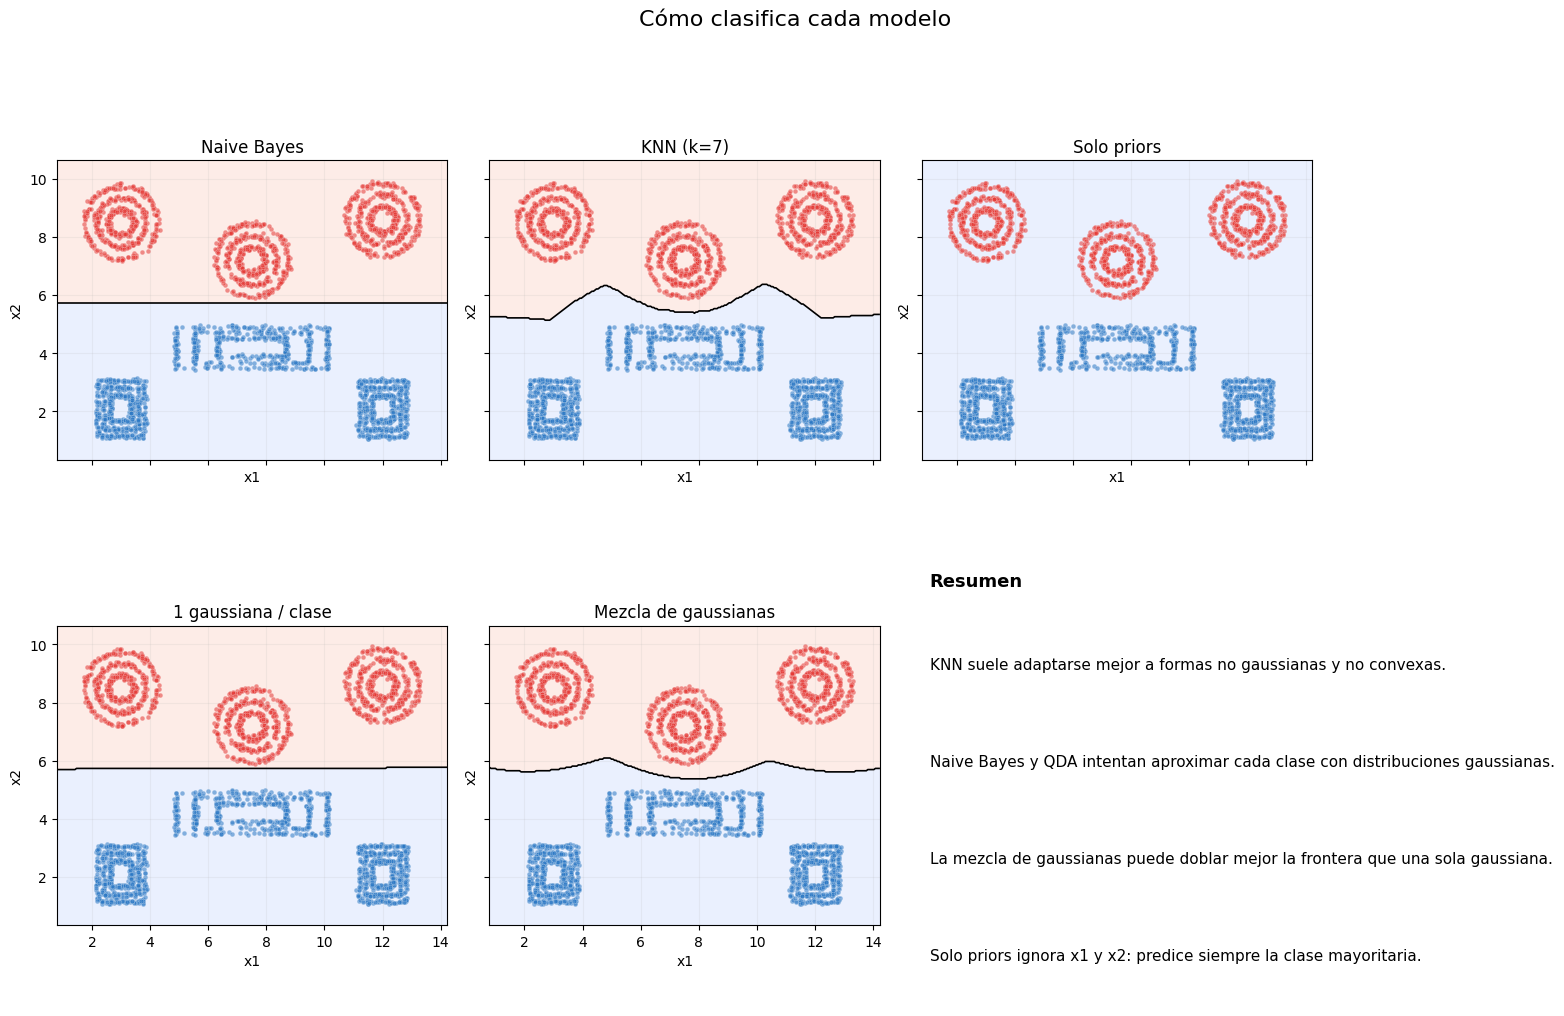

In [31]:
def make_grid(X, steps=260, padding=0.08):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    dx = (x_max - x_min) * padding
    dy = (y_max - y_min) * padding
    xx, yy = np.meshgrid(np.linspace(x_min - dx, x_max + dx, steps), np.linspace(y_min - dy, y_max + dy, steps))
    return xx, yy, np.column_stack([xx.ravel(), yy.ravel()])

def plot_regions(ax, model, name, X, y, xx, yy, grid, palette):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-0.5, len(np.unique(y)) - 0.5, len(np.unique(y)) + 1), cmap=plt.cm.coolwarm, alpha=0.18)
    if len(np.unique(y)) == 2:
        ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.2)
    for cls, color in palette.items():
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=12, c=color, alpha=0.55, edgecolors="white", linewidths=0.25)
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.15)

xx, yy, grid = make_grid(X)
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    plot_regions(ax, model, name, X, y, xx, yy, grid, palette)

axes[-1].axis("off")
axes[-1].text(0.02, 0.94, "Resumen", transform=axes[-1].transAxes, fontsize=13, fontweight="bold", va="top")
axes[-1].text(0.02, 0.73, "KNN suele adaptarse mejor a formas no gaussianas y no convexas.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.52, "Naive Bayes y QDA intentan aproximar cada clase con distribuciones gaussianas.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.31, "La mezcla de gaussianas puede doblar mejor la frontera que una sola gaussiana.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.10, "Solo priors ignora x1 y x2: predice siempre la clase mayoritaria.", transform=axes[-1].transAxes, fontsize=11)

fig.suptitle("Cómo clasifica cada modelo", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [32]:
df.to_csv("anillos_rectangulos_contornos.csv", index=False)
print("Archivo guardado como anillos_rectangulos_contornos.csv")

Archivo guardado como anillos_rectangulos_contornos.csv
